In [19]:
import sys

sys.path.append("..")
from utils import load_all_models_results

FOLDER_PATH = "../results/trying_other_models/"
PREFIX = "within_project_ASMOTE_"
# this shift controls wich metric we are using,
# 0 = f1-score
SHIFT = 0
results = load_all_models_results(folder_path=FOLDER_PATH, prefix=PREFIX, shift=SHIFT)

GRANULARITIES = ["file", "class", "method", "block"]

In [20]:
results

{'LightGBM':           Project  File  Class  Method  Block
 0          ANTLR4  34.0   38.0    23.0    6.0
 1         DBeaver  25.0   30.0    20.0   14.0
 2   Elasticsearch  36.0   34.0    15.0   12.0
 3       ExoPlayer  47.0   43.0    60.0   44.0
 4        FastJSON  29.0   24.0    71.0   81.0
 5           Flink  30.0   31.0    17.0   14.0
 6           Guava  63.0   59.0    42.0   70.0
 7         Jenkins  59.0   53.0    35.0   18.0
 8          LibGDX  34.0   32.0    59.0   44.0
 9        Logstash  12.0   33.0    20.0   17.0
 10        Mockito  29.0   31.0    27.0   14.0
 11     OpenRefine  40.0   44.0    36.0   31.0
 12         Presto  34.0   34.0    27.0   18.0
 13        Quarkus  40.0   41.0    29.0   20.0
 14        QuestDB  23.0   28.0    29.0   29.0
 15       Redisson  47.0   35.0    64.0   83.0
 16         RxJava  51.0   48.0    72.0   53.0
 17           Tink  71.0   69.0    64.0   20.0,
 'LogisticRegression':           Project   File  Class  Method  Block
 0          ANTLR4  32.3

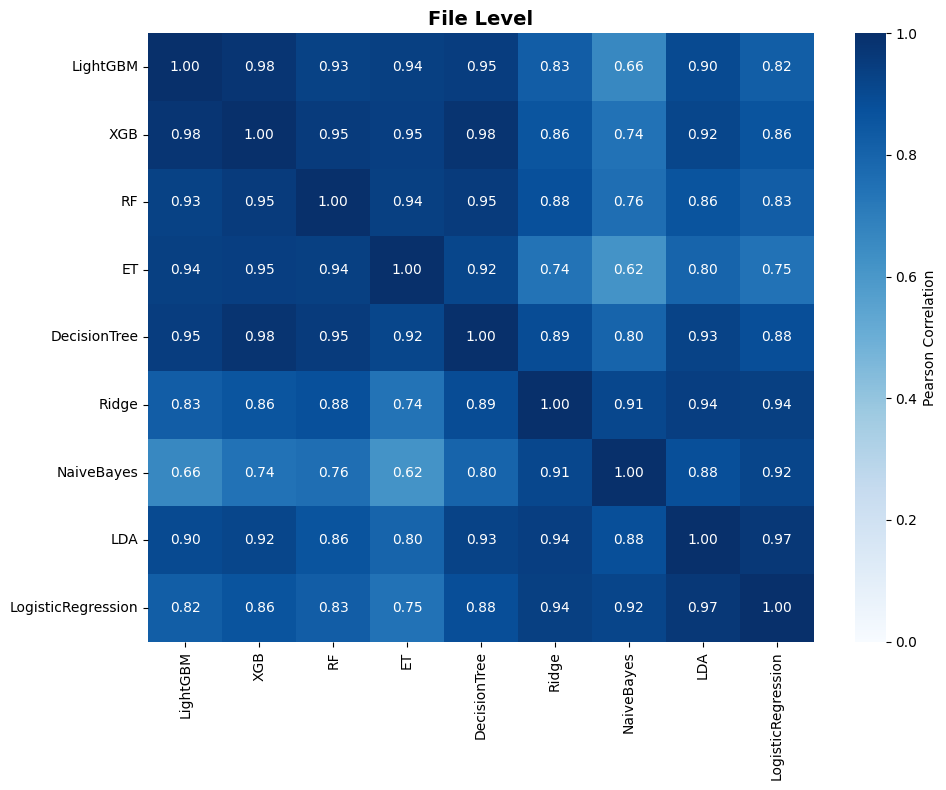

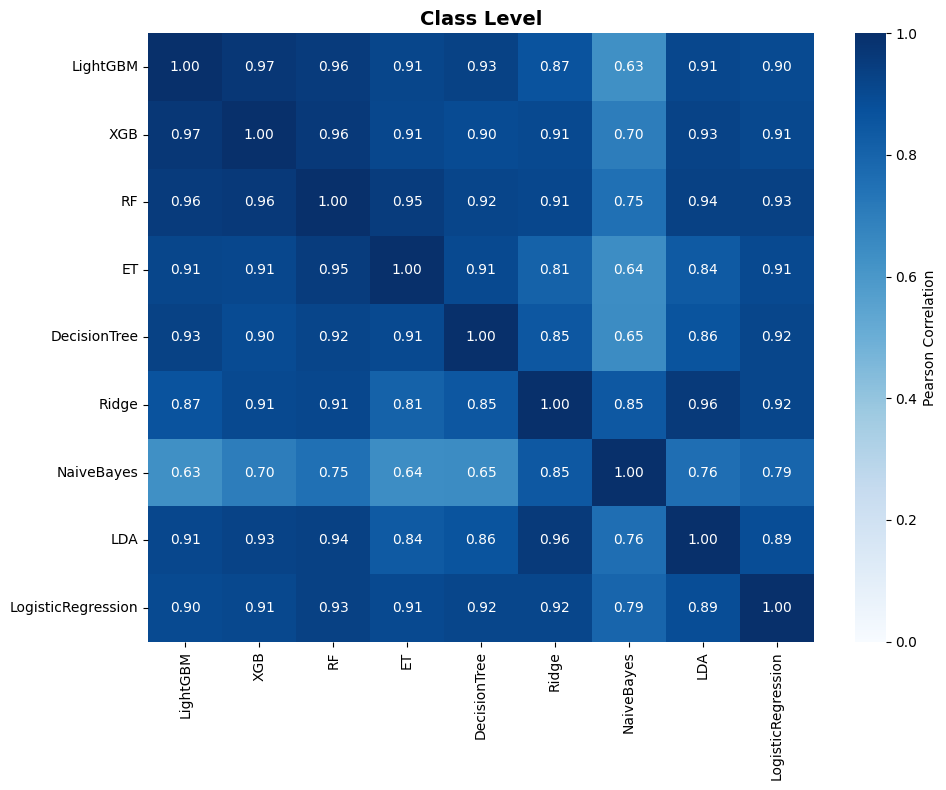

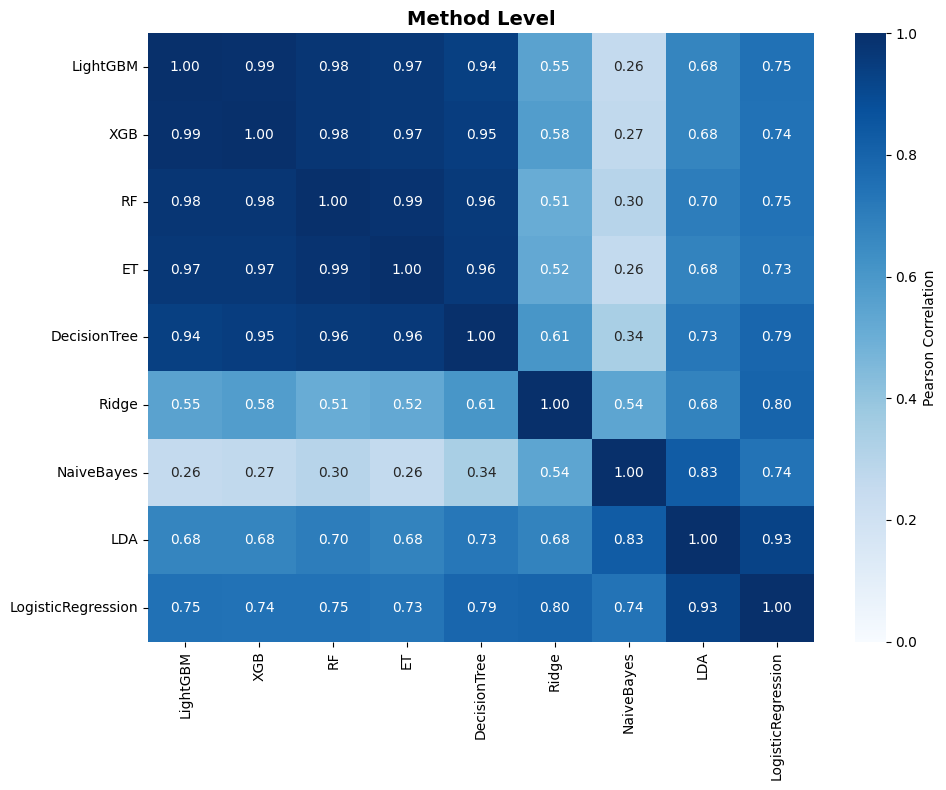

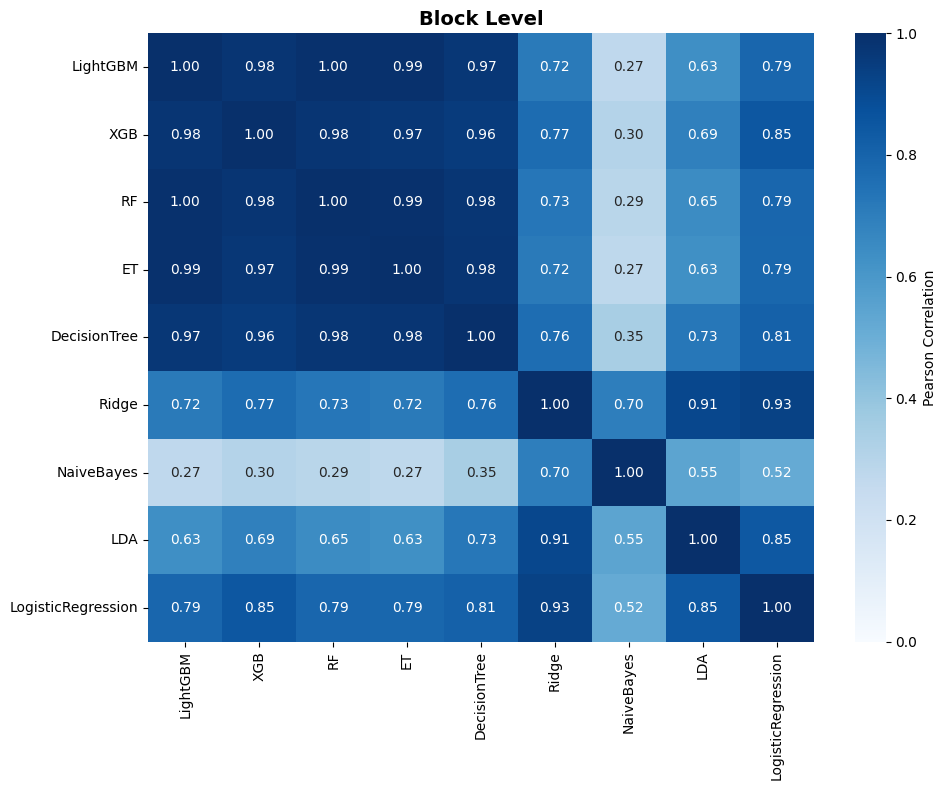

In [30]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ==========================================
# 1. DEFINE YOUR MANUAL MODEL ORDER HERE
# ==========================================
# Put the exact model names in the order you want them on the axes:
MANUAL_MODEL_ORDER = [
    "LightGBM",
    "XGB",
    "RF",
    "ET",
    "DecisionTree",
    "Ridge",
    "NaiveBayes",
    "LDA",
    "LogisticRegression"
    # Add all your model names here...
]

assert set(MANUAL_MODEL_ORDER) == set(results.keys())


def get_correlation_matrix(
    results_dict,
    target_level="Method",
    method="pearson",
    plot=True,
    custom_order=None,
):
    """Extracts performance for a granularity level across models and computes the correlation matrix.

    Parameters:
    - results_dict: dict of DataFrames keyed by model name.
    - target_level: 'File', 'Class', 'Method', or 'Block'
    - method: 'pearson' or 'spearman'
    - plot: bool, whether to display the heatmap
    - custom_order: list of str, explicit manual order for models
    """
    # Build pivot DataFrame: rows = Projects, columns = Models
    df_level = pd.DataFrame()
    for model_name, df in results_dict.items():
        df_level[model_name] = df.set_index("Project")[target_level]

    # Enforce custom order if provided
    if custom_order:
        # Get models present in the dict that weren't included in custom_order
        missing_models = [m for m in df_level.columns if m not in custom_order]
        # Full ordered list (manual order + any leftover models)
        full_order = [m for m in custom_order if m in df_level.columns] + missing_models
        # Reorder columns before computing correlation
        df_level = df_level[full_order]

    # Calculate correlation matrix (inherits the column ordering)
    corr_matrix = df_level.corr(method=method)

    if plot:
        plt.figure(figsize=(10, 8))
        sns.heatmap(
            corr_matrix,
            annot=True,
            fmt=".2f",
            cmap="Blues",
            vmin=0,
            vmax=1,
            cbar_kws={"label": f"{method.capitalize()} Correlation"},
        )
        plt.title(
            f"{target_level} Level",
            # f" {method.capitalize()})",
            fontsize=14,
            fontweight="bold",
        )
        plt.tight_layout()
        plt.show()

    return corr_matrix


# ==========================================
# 2. RUN WITH YOUR MANUAL ORDER
# ==========================================
corr_matrices = [
    get_correlation_matrix(
        results,
        target_level=granularity.capitalize(),
        method="pearson",
        plot=True,
        custom_order=MANUAL_MODEL_ORDER,  # Passes your manual list
    )
    for granularity in GRANULARITIES
]